In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output

In [2]:
results_folder = "../results/Navigation/3D"
create_folder(results_folder)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [3]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3174,512,3000,0.000001,2,0.011030,1.0,0.1,1,50,0.250182,0.000059,2850.780,29.863066,9539302.540,74998.156117
3175,512,3000,0.000001,2,0.011030,1.0,0.1,2,50,0.250117,0.000059,2955.000,24.991884,9540105.360,75031.676194
2872,512,3000,0.000001,2,0.013538,1.0,0.1,1,50,0.250046,0.000060,2803.360,28.682509,9373935.240,81298.242872
2873,512,3000,0.000001,2,0.013538,1.0,0.1,2,50,0.250218,0.000058,2899.700,27.087119,9374516.820,81230.615244
3082,512,3000,0.000001,2,0.016045,1.0,0.1,1,50,0.250156,0.000059,2891.320,27.316773,9633124.940,77766.680260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,128,3000,0.000001,2,0.497490,1.0,0.1,2,500,0.368663,0.000480,144.844,0.203219,992574.624,3070.589961
2542,256,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
3278,128,3000,0.000001,2,0.500000,1.0,0.1,1,500,0.556922,0.000929,144.390,0.165658,897404.110,2668.764902
2543,256,3000,0.000001,2,0.500000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


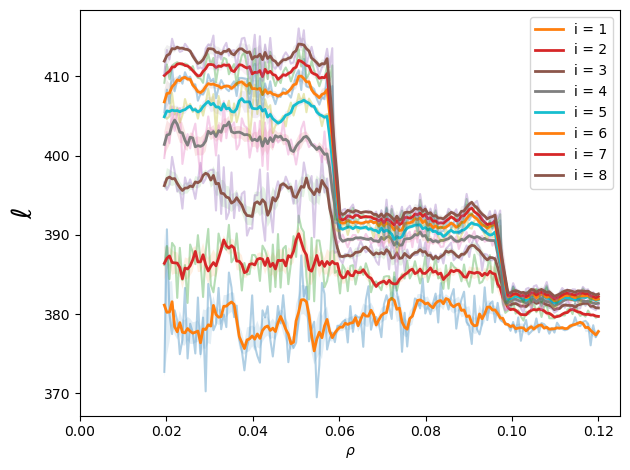

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
nc = 8
orders = [i for i in range(1, nc+1)]
P0 = 0.1
p0 = 1.0
WINDOW = 5  # nº de pontos na janela (ajuste conforme quiser)

#plt.figure(figsize=(10,4))

for order in orders:
    df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
    df_f = df_f.sort_values("rho")  # garante ordem crescente no eixo x

    x = df_f["rho"].to_numpy()
    y = df_f["shortest_path"].to_numpy()

    # média móvel centrada
    y_ma = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .mean()
        .to_numpy()
    )

    # desvio padrão na janela e erro padrão da média
    y_std = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .std()
        .to_numpy()
    )
    y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))  # aproxima

    # série original (mais clarinha) + média móvel
    plt.plot(x, y, alpha=0.35)
    plt.plot(x, y_ma, linewidth=2, label=f"i = {order}")

    # faixa opcional de incerteza (comente se não quiser)
    plt.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

plt.legend()
plt.xlabel(r"$\rho$")
#plt.axhline(y=0.24881182, xmin=0, xmax=0.5)
plt.ylabel(r"$\ell$", fontsize=20)
plt.xlim([0, 1/nc ])
plt.tight_layout()
plt.show()

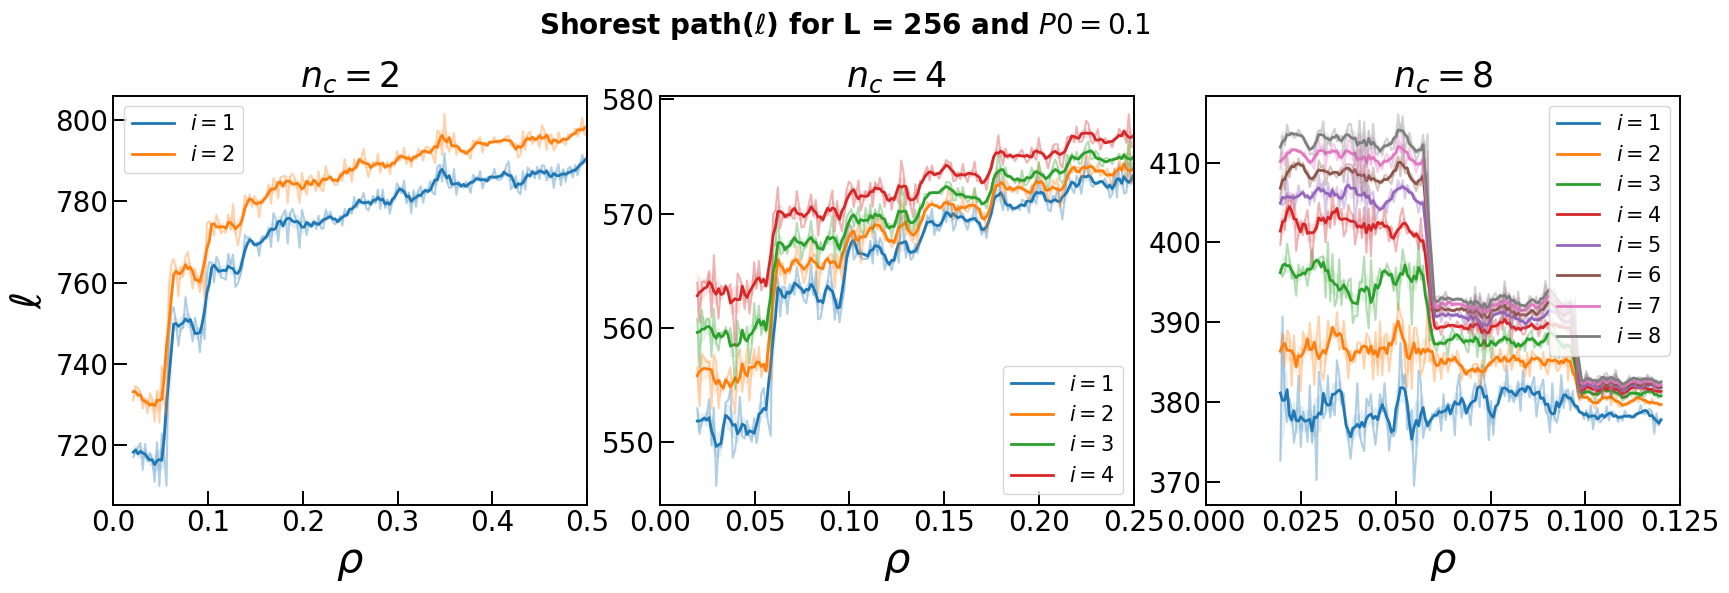

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
#ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4

for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["shortest_path"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2,color=colors[count] ,label=f"$i = {order}$")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
axes[0].set_ylabel(r"$\ell$",fontsize=30)
fig.suptitle(fr"Shorest path($\ell$) for L = {L} and $P0 = {P0}$", fontsize=20, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_fi

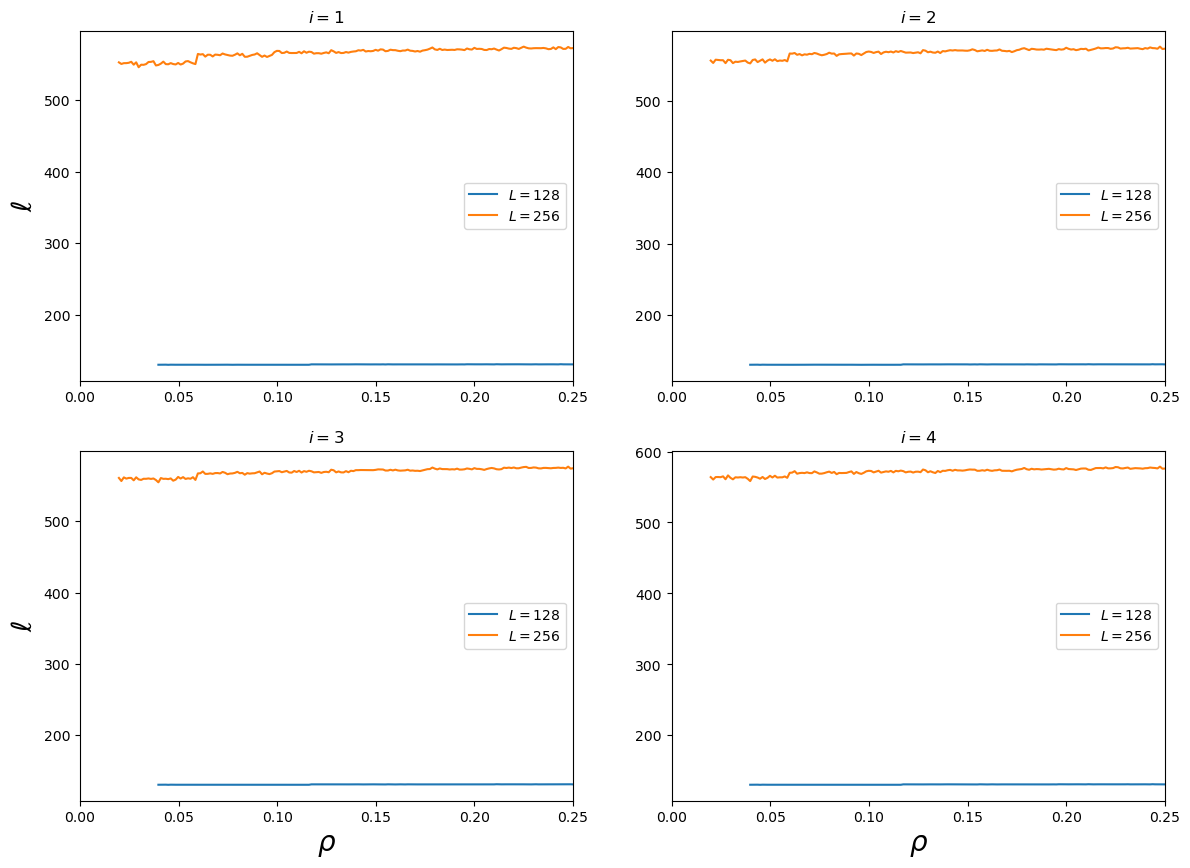

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = [128, 256]
Nc = 4
WINDOW = 5
P0 = 0.1
p0 = 1.0
orders = [i for i in range(1,5)]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
thickness_axes = 1.4
axs = [ax for ax in axes.flatten()]
df_filter = df[(df["nc"]==4) & (df["p0"]==1.0)]

for idx, ord in enumerate(orders):
    for l in L:
        df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
        axs[idx].plot(df_['rho'], df_['shortest_path'], label=f'$L = {l}$')

for idx, ax in enumerate(axs):
    ax.set_xlim(0, 0.25)
    ax.set_title(f"$i={idx+1}$")
    ax.legend()

for ax in axes[:,0]:
    ax.set_ylabel(r"$\ell$", fontsize=20)
for ax in axes[1,:]:
    ax.set_xlabel(r"$\rho$", fontsize=20)
plt.show()

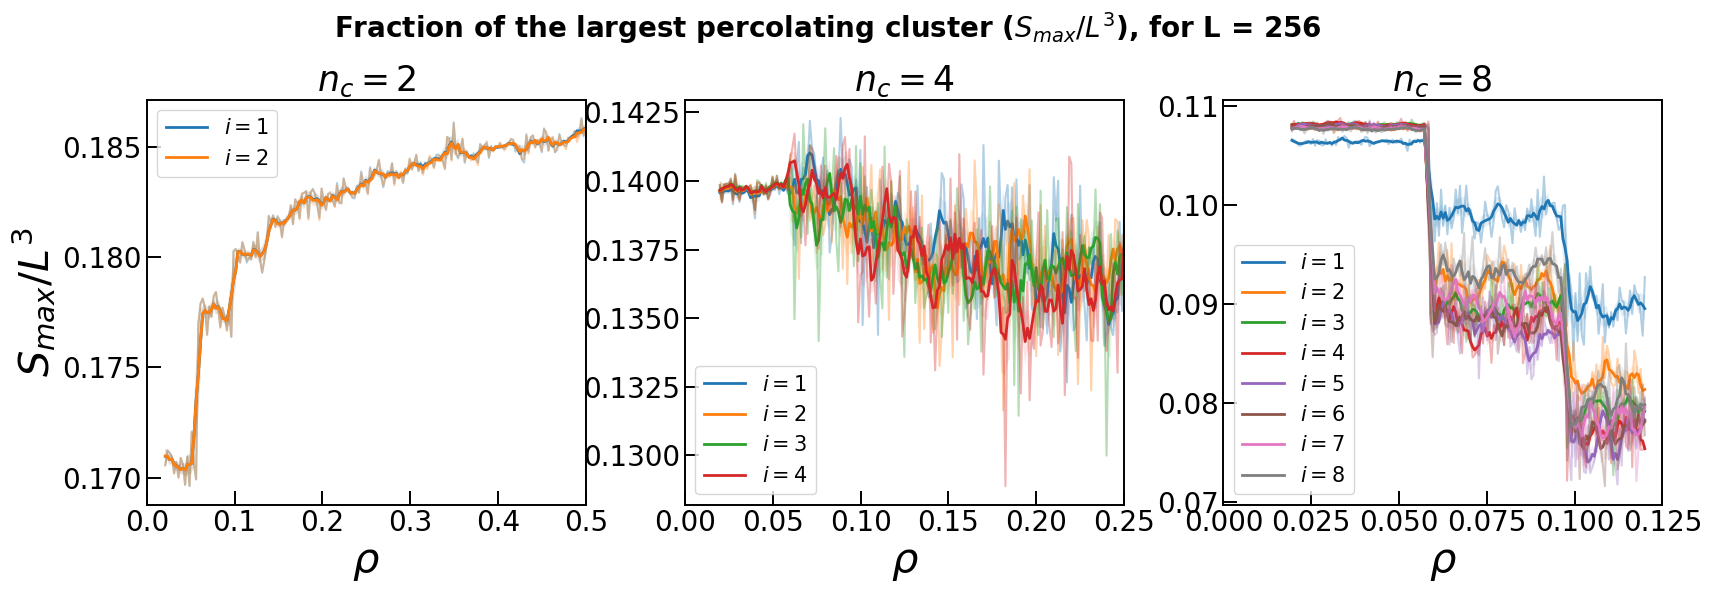

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
VOL = L**3
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
#ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4

for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["S_perc"].to_numpy()/VOL

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2,color=colors[count] ,label=f"$i = {order}$")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
axes[0].set_ylabel(r"$S_{max}/L^3$",fontsize=30)
fig.suptitle(fr"Fraction of the largest percolating cluster ($S_{{max}}/L^3$), for L = {L}", fontsize=20, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()

#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()
